In [ ]:
### R3P4 Rebuttal 2 stage

In [ ]:
# seed 40 Exp 2
# PD [1e-3,64,20],
# MP [1e-4,32,10],
# FP [1e-4,32,10]

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 244MB/s]


Total samples: 2702
Samples classified as HC: 1864
Precision: 0.9676
Recall: 0.9678
F1 Score: 0.9675
MCC: 0.9356


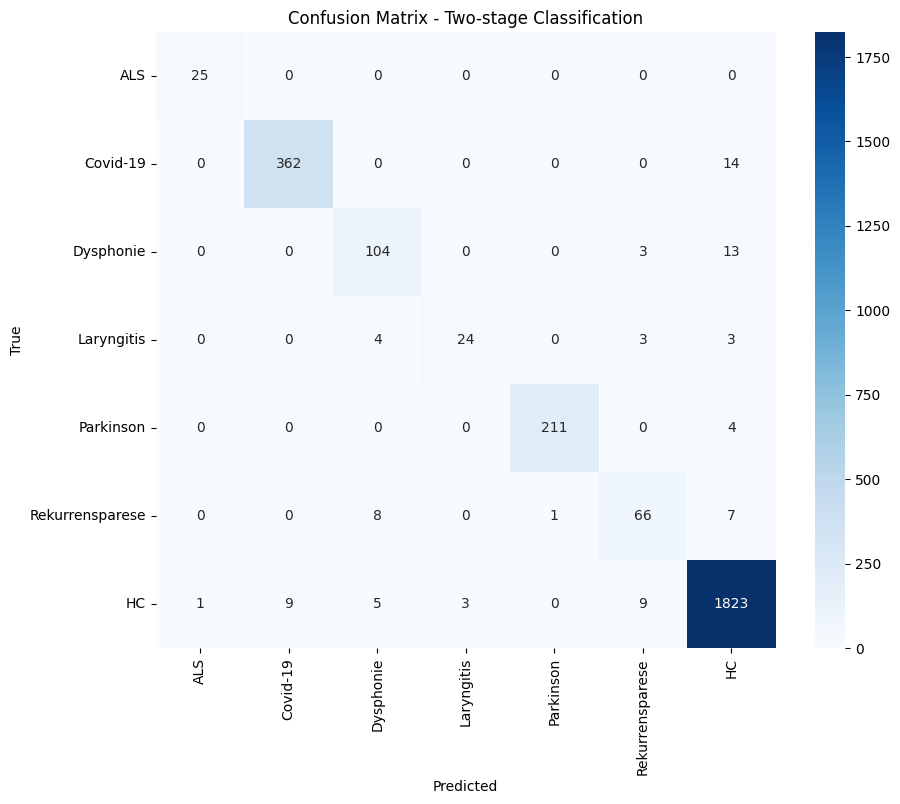

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import matthews_corrcoef, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models
from torchvision.models import ResNet50_Weights

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Class Mapping
group_classes = {"MC": 0, "MP": 1, "FC": 2, "FP": 3}
disease_classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5,
    "HC": 6
}

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

def load_model(model_path, num_classes):
    model = ResNet50Classifier(num_classes=num_classes).to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def get_test_loader(test_files, test_labels, batch_size=32):
    test_dataset = MelDataset(test_files, test_labels)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load Group Classifier
group_model = load_model("/content/MA/final_group_classifier.pth", num_classes=4)

# Load MP and FP Classifier
mp_model = load_model("/content/MA/best_resnet50_MP_model.pth", num_classes=6)
fp_model = load_model("/content/MA/best_resnet50_FP_model.pth", num_classes=6)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in disease_classes:
            files.append(full_path)
            labels.append(disease_classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

test_set_path = os.path.join("/content/MA", "test_set.xlsx")
test_df = pd.read_excel(test_set_path)
test_files, test_labels = get_file_paths_and_labels(test_df, "/content/MA")

test_loader = get_test_loader(test_files, test_labels)

y_true, y_pred = [], []

total_samples, mc_fc_count = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.numpy()
        if len(inputs.shape) == 5:
            inputs = inputs.squeeze(2)
        group_outputs = group_model(inputs)
        group_preds = torch.argmax(group_outputs, axis=1).cpu().numpy()

        for i, group_pred in enumerate(group_preds):
            if group_pred in [group_classes["MC"], group_classes["FC"]]:
                y_true.append(labels[i])
                y_pred.append(disease_classes["HC"])
                mc_fc_count += 1
            elif group_pred == group_classes["MP"]:
                mp_output = mp_model(inputs[i].unsqueeze(0))
                mp_pred = torch.argmax(mp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(mp_pred)
            elif group_pred == group_classes["FP"]:
                fp_output = fp_model(inputs[i].unsqueeze(0))
                fp_pred = torch.argmax(fp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(fp_pred)

print(f"Total samples: {len(test_labels)}")
print(f"Samples classified as HC: {mc_fc_count}")

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_classes.keys(),
            yticklabels=disease_classes.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Two-stage Classification")
plt.show()


In [ ]:
# seed 41 Exp 2
# PD [1e-3,64,30],
# MP [1e-4,32,20],
# FP [1e-3,32,30]


Using device: cuda
Total samples: 2702
Samples classified as HC: 1914
Precision: 0.9588
Recall: 0.9585
F1 Score: 0.9578
MCC: 0.9164


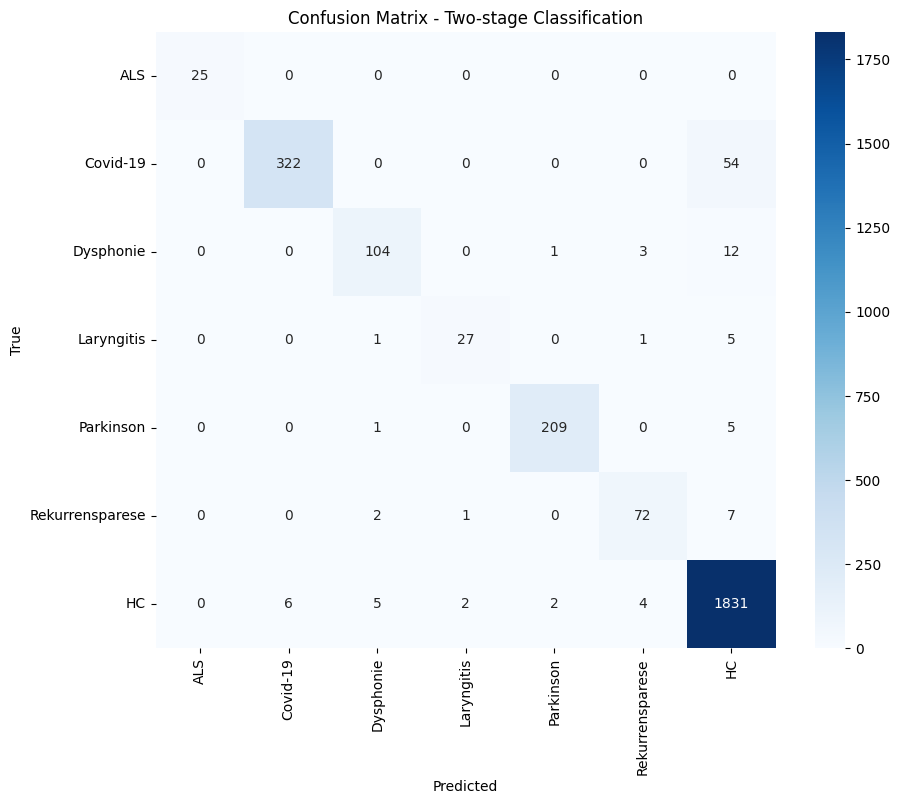

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import matthews_corrcoef, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models
from torchvision.models import ResNet50_Weights

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Class Mapping
group_classes = {"MC": 0, "MP": 1, "FC": 2, "FP": 3}
disease_classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5,
    "HC": 6
}

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

def load_model(model_path, num_classes):
    model = ResNet50Classifier(num_classes=num_classes).to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def get_test_loader(test_files, test_labels, batch_size=32):
    test_dataset = MelDataset(test_files, test_labels)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load Group Classifier
group_model = load_model("/content/MA/final_group_classifier.pth", num_classes=4)

# Load MP and FP Classifier
mp_model = load_model("/content/MA/best_resnet50_MP_model.pth", num_classes=6)
fp_model = load_model("/content/MA/best_resnet50_FP_model.pth", num_classes=6)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in disease_classes:
            files.append(full_path)
            labels.append(disease_classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

test_set_path = os.path.join("/content/MA", "test_set.xlsx")
test_df = pd.read_excel(test_set_path)
test_files, test_labels = get_file_paths_and_labels(test_df, "/content/MA")

test_loader = get_test_loader(test_files, test_labels)

y_true, y_pred = [], []

total_samples, mc_fc_count = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.numpy()
        if len(inputs.shape) == 5:
            inputs = inputs.squeeze(2)
        group_outputs = group_model(inputs)
        group_preds = torch.argmax(group_outputs, axis=1).cpu().numpy()

        for i, group_pred in enumerate(group_preds):
            if group_pred in [group_classes["MC"], group_classes["FC"]]:
                y_true.append(labels[i])
                y_pred.append(disease_classes["HC"])
                mc_fc_count += 1
            elif group_pred == group_classes["MP"]:
                mp_output = mp_model(inputs[i].unsqueeze(0))
                mp_pred = torch.argmax(mp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(mp_pred)
            elif group_pred == group_classes["FP"]:
                fp_output = fp_model(inputs[i].unsqueeze(0))
                fp_pred = torch.argmax(fp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(fp_pred)

print(f"Total samples: {len(test_labels)}")
print(f"Samples classified as HC: {mc_fc_count}")

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_classes.keys(),
            yticklabels=disease_classes.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Two-stage Classification")
plt.show()


In [ ]:
# seed 40 Exp 3.1
# PD [1e-4,64,30],
# MP [1e-4,32,30],
# FP [1e-4,32,30]


Using device: cuda
Total samples: 2702
Samples classified as HC: 1898
Precision: 0.9623
Recall: 0.9626
F1 Score: 0.9620
MCC: 0.9246


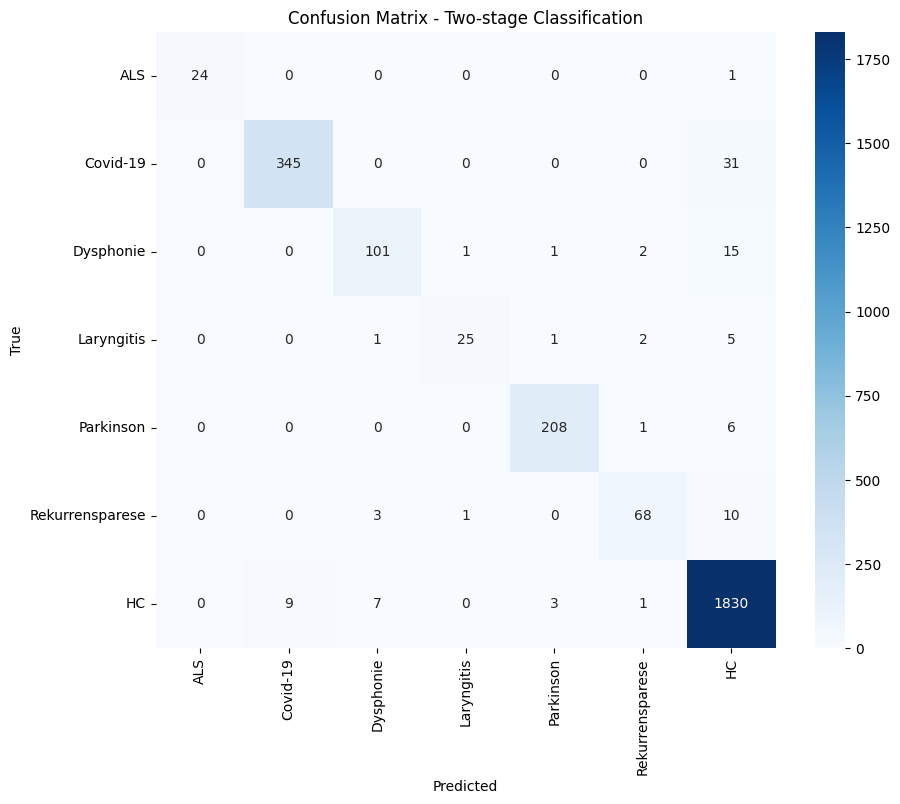

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import matthews_corrcoef, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models
from torchvision.models import ResNet50_Weights

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Class Mapping
group_classes = {"MC": 0, "MP": 1, "FC": 2, "FP": 3}
disease_classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5,
    "HC": 6
}

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

def load_model(model_path, num_classes):
    model = ResNet50Classifier(num_classes=num_classes).to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def get_test_loader(test_files, test_labels, batch_size=32):
    test_dataset = MelDataset(test_files, test_labels)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load Group Classifier
group_model = load_model("/content/MA/final_group_classifier.pth", num_classes=4)

# Load MP and FP Classifier
mp_model = load_model("/content/MA/best_resnet50_MP_model.pth", num_classes=6)
fp_model = load_model("/content/MA/best_resnet50_FP_model.pth", num_classes=6)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in disease_classes:
            files.append(full_path)
            labels.append(disease_classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

test_set_path = os.path.join("/content/MA", "test_set.xlsx")
test_df = pd.read_excel(test_set_path)
test_files, test_labels = get_file_paths_and_labels(test_df, "/content/MA")

test_loader = get_test_loader(test_files, test_labels)

y_true, y_pred = [], []

total_samples, mc_fc_count = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.numpy()
        if len(inputs.shape) == 5:
            inputs = inputs.squeeze(2)
        group_outputs = group_model(inputs)
        group_preds = torch.argmax(group_outputs, axis=1).cpu().numpy()

        for i, group_pred in enumerate(group_preds):
            if group_pred in [group_classes["MC"], group_classes["FC"]]:
                y_true.append(labels[i])
                y_pred.append(disease_classes["HC"])
                mc_fc_count += 1
            elif group_pred == group_classes["MP"]:
                mp_output = mp_model(inputs[i].unsqueeze(0))
                mp_pred = torch.argmax(mp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(mp_pred)
            elif group_pred == group_classes["FP"]:
                fp_output = fp_model(inputs[i].unsqueeze(0))
                fp_pred = torch.argmax(fp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(fp_pred)

print(f"Total samples: {len(test_labels)}")
print(f"Samples classified as HC: {mc_fc_count}")

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_classes.keys(),
            yticklabels=disease_classes.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Two-stage Classification")
plt.show()


In [ ]:
# seed 41 Exp 3.1
# PD [1e-4,32,30],
# MP [1e-4,64,30],
# FP [1e-4,32,20]


Using device: cuda
Total samples: 2702
Samples classified as HC: 1868
Precision: 0.9635
Recall: 0.9641
F1 Score: 0.9636
MCC: 0.9281


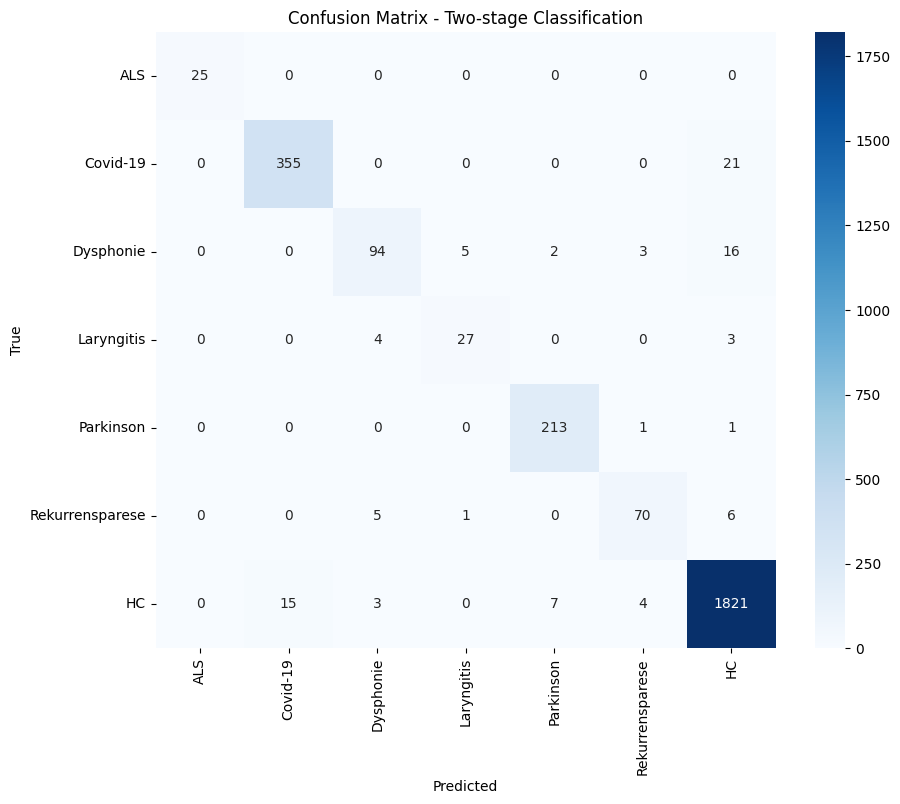

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import matthews_corrcoef, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models
from torchvision.models import ResNet50_Weights

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Class Mapping
group_classes = {"MC": 0, "MP": 1, "FC": 2, "FP": 3}
disease_classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5,
    "HC": 6
}

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

def load_model(model_path, num_classes):
    model = ResNet50Classifier(num_classes=num_classes).to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def get_test_loader(test_files, test_labels, batch_size=32):
    test_dataset = MelDataset(test_files, test_labels)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load Group Classifier
group_model = load_model("/content/MA/final_group_classifier.pth", num_classes=4)

# Load MP and FP Classifier
mp_model = load_model("/content/MA/best_resnet50_MP_model.pth", num_classes=6)
fp_model = load_model("/content/MA/best_resnet50_FP_model.pth", num_classes=6)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in disease_classes:
            files.append(full_path)
            labels.append(disease_classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

test_set_path = os.path.join("/content/MA", "test_set.xlsx")
test_df = pd.read_excel(test_set_path)
test_files, test_labels = get_file_paths_and_labels(test_df, "/content/MA")

test_loader = get_test_loader(test_files, test_labels)

y_true, y_pred = [], []

total_samples, mc_fc_count = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.numpy()
        if len(inputs.shape) == 5:
            inputs = inputs.squeeze(2)
        group_outputs = group_model(inputs)
        group_preds = torch.argmax(group_outputs, axis=1).cpu().numpy()

        for i, group_pred in enumerate(group_preds):
            if group_pred in [group_classes["MC"], group_classes["FC"]]:
                y_true.append(labels[i])
                y_pred.append(disease_classes["HC"])
                mc_fc_count += 1
            elif group_pred == group_classes["MP"]:
                mp_output = mp_model(inputs[i].unsqueeze(0))
                mp_pred = torch.argmax(mp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(mp_pred)
            elif group_pred == group_classes["FP"]:
                fp_output = fp_model(inputs[i].unsqueeze(0))
                fp_pred = torch.argmax(fp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(fp_pred)

print(f"Total samples: {len(test_labels)}")
print(f"Samples classified as HC: {mc_fc_count}")

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_classes.keys(),
            yticklabels=disease_classes.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Two-stage Classification")
plt.show()


In [ ]:
# seed 40 Exp 3.2
# PD [1e-4,32,30],
# MP [1e-3,64,30],
# FP [1e-4,64,30]

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s]


Total samples: 2702
Samples classified as HC: 1868
Precision: 0.9687
Recall: 0.9689
F1 Score: 0.9686
MCC: 0.9377


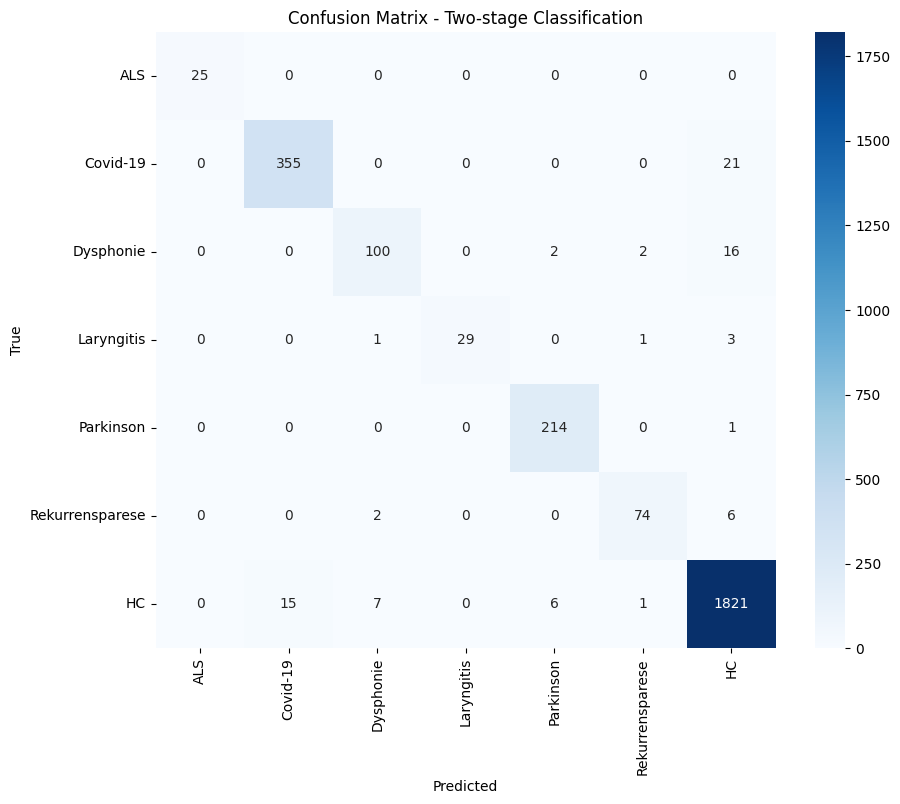

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import matthews_corrcoef, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models
from torchvision.models import ResNet50_Weights

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Class Mapping
group_classes = {"MC": 0, "MP": 1, "FC": 2, "FP": 3}
disease_classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5,
    "HC": 6
}

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

def load_model(model_path, num_classes):
    model = ResNet50Classifier(num_classes=num_classes).to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def get_test_loader(test_files, test_labels, batch_size=32):
    test_dataset = MelDataset(test_files, test_labels)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load Group Classifier
group_model = load_model("/content/MA/final_group_classifier.pth", num_classes=4)

# Load MP and FP Classifier
mp_model = load_model("/content/MA/best_resnet50_MP_model.pth", num_classes=6)
fp_model = load_model("/content/MA/best_resnet50_FP_model.pth", num_classes=6)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in disease_classes:
            files.append(full_path)
            labels.append(disease_classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

test_set_path = os.path.join("/content/MA", "test_set.xlsx")
test_df = pd.read_excel(test_set_path)
test_files, test_labels = get_file_paths_and_labels(test_df, "/content/MA")

test_loader = get_test_loader(test_files, test_labels)

y_true, y_pred = [], []

total_samples, mc_fc_count = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.numpy()
        if len(inputs.shape) == 5:
            inputs = inputs.squeeze(2)
        group_outputs = group_model(inputs)
        group_preds = torch.argmax(group_outputs, axis=1).cpu().numpy()

        for i, group_pred in enumerate(group_preds):
            if group_pred in [group_classes["MC"], group_classes["FC"]]:
                y_true.append(labels[i])
                y_pred.append(disease_classes["HC"])
                mc_fc_count += 1
            elif group_pred == group_classes["MP"]:
                mp_output = mp_model(inputs[i].unsqueeze(0))
                mp_pred = torch.argmax(mp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(mp_pred)
            elif group_pred == group_classes["FP"]:
                fp_output = fp_model(inputs[i].unsqueeze(0))
                fp_pred = torch.argmax(fp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(fp_pred)

print(f"Total samples: {len(test_labels)}")
print(f"Samples classified as HC: {mc_fc_count}")

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_classes.keys(),
            yticklabels=disease_classes.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Two-stage Classification")
plt.show()


In [ ]:
# seed 41 Exp 3.2
# PD [1e-4,32,30],
# MP [1e-4,32,30]
# FP [1e-3,64,20]

Using device: cuda
Total samples: 2702
Samples classified as HC: 1834
Precision: 0.9725
Recall: 0.9719
F1 Score: 0.9721
MCC: 0.9445


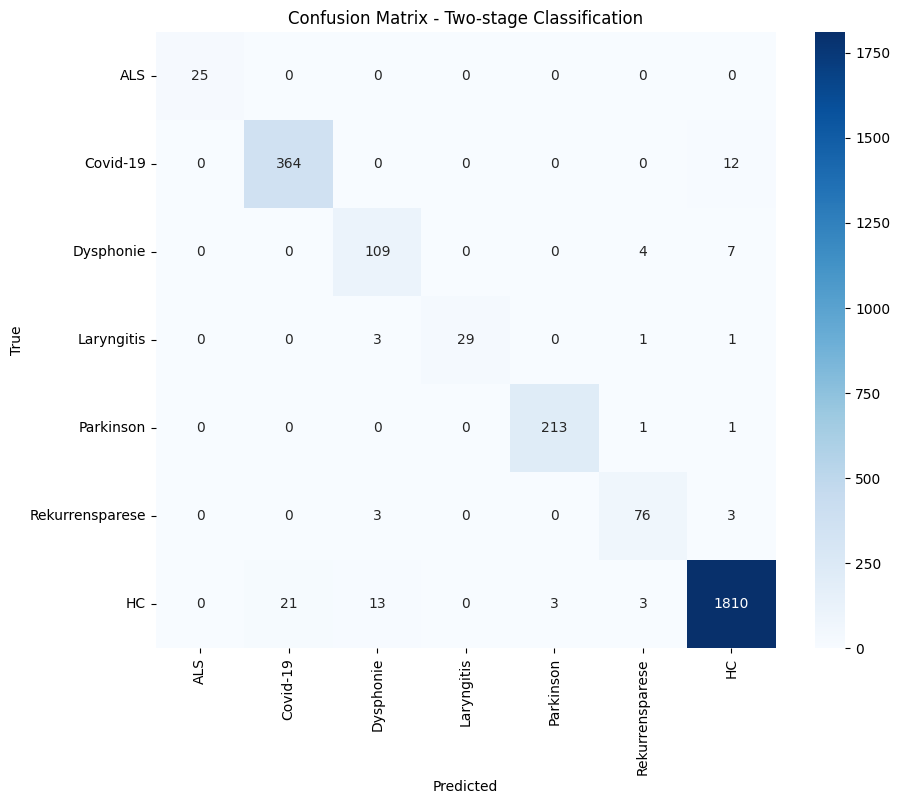

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import matthews_corrcoef, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models
from torchvision.models import ResNet50_Weights

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Class Mapping
group_classes = {"MC": 0, "MP": 1, "FC": 2, "FP": 3}
disease_classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5,
    "HC": 6
}

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

def load_model(model_path, num_classes):
    model = ResNet50Classifier(num_classes=num_classes).to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def get_test_loader(test_files, test_labels, batch_size=32):
    test_dataset = MelDataset(test_files, test_labels)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load Group Classifier
group_model = load_model("/content/MA/final_group_classifier.pth", num_classes=4)

# Load MP and FP Classifier
mp_model = load_model("/content/MA/best_resnet50_MP_model.pth", num_classes=6)
fp_model = load_model("/content/MA/best_resnet50_FP_model.pth", num_classes=6)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in disease_classes:
            files.append(full_path)
            labels.append(disease_classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

test_set_path = os.path.join("/content/MA", "test_set.xlsx")
test_df = pd.read_excel(test_set_path)
test_files, test_labels = get_file_paths_and_labels(test_df, "/content/MA")

test_loader = get_test_loader(test_files, test_labels)

y_true, y_pred = [], []

total_samples, mc_fc_count = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.numpy()
        if len(inputs.shape) == 5:
            inputs = inputs.squeeze(2)
        group_outputs = group_model(inputs)
        group_preds = torch.argmax(group_outputs, axis=1).cpu().numpy()

        for i, group_pred in enumerate(group_preds):
            if group_pred in [group_classes["MC"], group_classes["FC"]]:
                y_true.append(labels[i])
                y_pred.append(disease_classes["HC"])
                mc_fc_count += 1
            elif group_pred == group_classes["MP"]:
                mp_output = mp_model(inputs[i].unsqueeze(0))
                mp_pred = torch.argmax(mp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(mp_pred)
            elif group_pred == group_classes["FP"]:
                fp_output = fp_model(inputs[i].unsqueeze(0))
                fp_pred = torch.argmax(fp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(fp_pred)

print(f"Total samples: {len(test_labels)}")
print(f"Samples classified as HC: {mc_fc_count}")

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_classes.keys(),
            yticklabels=disease_classes.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Two-stage Classification")
plt.show()
